# **Lab 6: Inference for Regression**

In Section 6, you fitted a line. This section asks the harder question: **could the
relationship you found be nothing at all?**

Your slope came from a sample. A different sample would give a different slope.
**Noise** means two columns with no relationship at all. Give the regression
formula noise and it still returns a slope. So a slope on its own is not
evidence.

The answer is the bootstrap. This lab shows you the whole method before asking
you to use it.

There are no hidden tests. Every test that counts is in the `tests` folder and
you can run all of them yourself. The test for Question 4.4 compares a scrambled
form of your answer rather than storing it in plain text, so reading the test file
will not give you the answer. Running the test will still tell you whether you
are right.

**Sections 1 and 3 are worked demonstrations with nothing to answer.** The
questions therefore run 2.1, 2.2, then 4.1 to 4.4. A question number is its
section number and its place in that section, so nothing is missing.

**Points: 50.** Q2.1 (8), Q2.2 (4), Q4.1 (14), Q4.2 (14), Q4.3 (6), Q4.4 (4).

#### **Helpful Resource:**
- [Python Reference](https://ulwazi.wits.ac.za/courses/89081/pages/detailed-python-reference-sheet-python-cheat-sheet-2?module_item_id=1200407)

**Recommended Readings:**
- [15.4 Least Squares Regression](https://www.inferentialthinking.com/chapters/15/4/Least_Squares_Regression)
and
- [16.2 Inference for the True Slope](https://inferentialthinking.com/chapters/16/2/Inference_for_the_True_Slope.html).

## *Do not change the code in the two cells below* ##

In [1]:
# Run this cell first to install the libraries. It may take a minute.
%pip install -q urllib3<2.0 otter-grader==7.0.0 datascience ipywidgets

In [2]:
# Run this cell to set up the notebook, but please don't change it.

try:
    import pyodide_http
    pyodide_http.patch_all()
except ImportError:
    pass

import numpy as np
from datascience import *

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plt = plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

import hashlib
import otter
grader = otter.Notebook("lab6.ipynb")

Matplotlib is building the font cache; this may take a moment.


---

### **If something goes wrong** (Refer to this if get an error)

Errors are normal. Everyone gets them, including people who have been doing this
for years. The message tells you what happened, once you know how to read it.

| What you see | What it usually means |
|---|---|
| `NameError: name 'x' is not defined` | You have not run the cell that creates `x`, or you typed it differently |
| `NameError: name 'Table' is not defined` | The setup cell at the very top has not been run. That is the cell that brings in `Table`, `np` and the plotting tools. Run it, then run your own cell again |
| `NameError: name 'grader' is not defined` | The same cause, for the cell that sets up the tests. If you did run it, read its output: the `otter` install needs a connection the first time, and if it failed then every `grader.check` below it fails too. Run that cell again |
| `ValueError: The column "X" is not in the table` | You typed a column name that does not exist. The message lists the real ones, so read to the end of it |
| `SyntaxError` | A missing bracket or quote, often on the line **above** the one it points at |
| `TypeError: unsupported operand` | Arithmetic on text, or on a whole table where you wanted one column |
| `IndexError` | You asked for item 5 of something with fewer than 6 things in it |
| `TypeError: f() missing 2 required positional arguments` | You called a function with too few arguments. Count what goes inside the brackets |
| `TypeError: '<' not supported between instances of 'NoneType' and 'NoneType'` | A function you wrote has no `return` line, so it hands back nothing, and something else then tried to use that nothing |
| `UnboundLocalError: cannot access local variable 'slope'` | Inside a function you gave a variable the same name as a function you then tried to call. Rename the variable |
| Anything that mentions `ellipsis` | A `...` is still there. Either in your own cell, or in a "just run this cell" further down that needs your answer first. Fill in the question above it and run again |

**If several cells stop making sense at once**, the cause is almost always that
they were run out of order. Choose **Kernel** then **Restart Kernel and Run All Cells**, and
work down from the top again.

Try things. Running something wrong and reading the error is how this is
learned, and you cannot break anything.

---

## **1. Why a slope alone means nothing**

The cell below re-defines the four functions you wrote in Lab 5, so this
notebook can be run without Lab 5. **You did not write them here and you will not be
asked to.**

In [3]:
# Just run this cell
def standard_units(x):
    return (x - np.mean(x)) / np.std(x)

def correlation(x, y):
    return np.mean(standard_units(x) * standard_units(y))

def slope(x, y):
    return correlation(x, y) * np.std(y) / np.std(x)

def intercept(x, y):
    return np.mean(y) - slope(x, y) * np.mean(x)

Now 40 points of pure noise: an `x` and a `y` drawn independently, with no
relationship between them whatsoever. The cell fits a line through them anyway,
and puts the slope it found in the title.

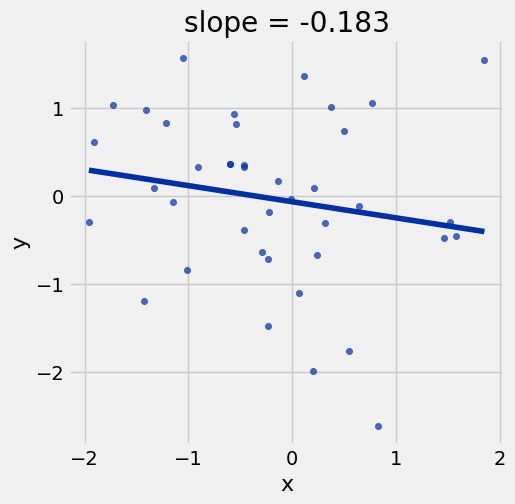

In [4]:
# Just run this cell
np.random.seed(42)
noise = Table().with_columns('x', np.random.normal(0, 1, 40),
                             'y', np.random.normal(0, 1, 40))
noise.scatter('x', 'y', fit_line=True)
plots.title('slope = ' + str(round(slope(noise.column('x'), noise.column('y')), 3)))
plots.show()

The line tilts. It always does, because a best-fitting line exists for any
scatter of points, related or not.

So how do you tell a real slope from that one? That question is answered in
Sections 3 and 4. Section 2 first finishes the story of the line itself. At the
very end of the lab you will come back and test this noise.

---
---

## **2. Least squares**

One more thing about the line itself. A prediction has an **error**: actual
minus predicted. That is the same quantity you called a **residual** in Lab 5,
under a different name, and you have already worked it out once. What is new
here is what we do with it next.

Errors are positive and negative, so squaring before averaging stops them
cancelling, and the square root at the end returns the answer to the original
units.

That is the **root mean squared error**, and the regression line is defined by a
single property: **no other line has a smaller one.**

Here is that arithmetic in code, on three made-up numbers. `make_array(...)`
builds an array from the values you put in it, and `**` raises to a power, so
`errors ** 2` squares every error.

In [5]:
# Just run this cell
actual    = make_array(10, 12, 15)
predicted = make_array(11, 11, 18)

errors = actual - predicted
print('errors:                   ', errors)
print('squared errors:           ', errors ** 2)
print('mean of the squares:      ', np.mean(errors ** 2))
print('square root of that (rmse):', np.sqrt(np.mean(errors ** 2)))

errors:                    [-1  1 -3]
squared errors:            [1 1 9]
mean of the squares:       3.66666666667
square root of that (rmse): 1.91485421551


Now the real data: the age and market value of 100 footballers.

In [6]:
# Just run this cell
fifa = Table.read_table('fifa22.csv').select('age', 'value_eur')
fifa.show(3)

age,value_eur
34,78000000
32,119500000
36,45000000


---

**Question 2.1. (8 points)** Define a function `rmse` that takes two arguments,
a slope and an intercept for a possible regression line, and returns the root
mean squared error between the values that line predicts and the actual
outcomes.

We are still predicting `value_eur` from `age`, in original units, from the
`fifa` table. **Your function takes no table argument.** When Python runs a
line inside a function and meets a name, it looks first at the names that
function made for itself: its arguments, and anything assigned inside its
body. If the name is not one of those, it looks outside, at the names defined
in the notebook. `fifa` is not an argument of `rmse`, and nothing inside
`rmse` assigns it, so Python looks outside and finds the table loaded in the
cell above.

The last line of the skeleton already says `return`, so put the expression for
the answer after it.

In [7]:
def rmse(any_slope, any_intercept):
    predictions = ...
    errors = ...
    return ...

In [8]:
grader.check("q2_1")

<class 'ValueError'>: Test q2_1 not found

---

**Question 2.2. (4 points)** Use your `rmse` function together with `minimize`
to find the least-squares slope and intercept for predicting `value_eur` from
`age`.

`minimize(f)` searches numerically for the arguments that make `f` smallest, and
returns them as an array in the order `f` takes them, so the slope first and
then the intercept. It knows nothing about correlation or standard units.

Two things that are easy to get wrong:

- `minimize` wants the function itself, `minimize(rmse)`, not the result of
  calling it. There are no brackets after `rmse`.
- `.item(0)` pulls the first thing out of an array, `.item(1)` the second.

In [ ]:
minimized_parameters = minimize(...)
lsq_slope = minimized_parameters.item(...)
lsq_intercept = minimized_parameters.item(...)

print("Slope: {:g} | Intercept: {:g}".format(lsq_slope, lsq_intercept))

In [ ]:
grader.check("q2_2")

Once 2.2 passes, run the cell below. It compares your answer to what last
Section's formula gives. (It needs `lsq_slope` and `lsq_intercept`, so it will
complain about an `ellipsis` if you run it before finishing 2.2.)

In [ ]:
# Just run this cell
formula_slope = slope(fifa.column('age'), fifa.column('value_eur'))
formula_intercept = intercept(fifa.column('age'), fifa.column('value_eur'))

print("               slope           intercept        rmse")
print("formula:  {:>12g}  {:>14g}  {:>12g}".format(
    formula_slope, formula_intercept, rmse(formula_slope, formula_intercept)))
print("minimize: {:>12g}  {:>14g}  {:>12g}".format(
    lsq_slope, lsq_intercept, rmse(lsq_slope, lsq_intercept)))

They agree, and that agreement is the point of this section. `minimize` knows
nothing about correlation, standard deviations or any formula for a line. It
simply tries slopes and intercepts and keeps the pair with the smallest error.
That it lands on the same line the formula gives is how you know the formula is
not an arbitrary recipe you were asked to trust: it is the line with the
smallest root mean squared error, and now you have seen that from two
directions.

> **If they ever disagree**, compare the two RMSEs in the last column. The
> formula's is provably the smallest possible, so a larger one from `minimize`
> means the search stopped short. That can happen when the two quantities are on
> very different scales.

---

## **3. The bootstrap, demonstrated**

Here is the method in full, with the answers shown. **Nothing in this section is
a question.** Read it, run it, and make sure you follow what each step does,
because Section 4 asks you to do the same thing to a slope.

The data is a study of snowy plovers, a small shorebird that nests on beaches.
Researchers weighed each egg, then weighed the chick that hatched from it.

<table><tr>
<td><img src="plover_and_eggs.jpeg" alt="An adult snowy plover sitting on three speckled eggs in a shallow scrape in the sand" width="330"></td>
<td><img src="plover_and_chick.jpeg" alt="An adult snowy plover standing over a chick sheltering beneath it" width="330"></td>
</tr></table>

In [ ]:
# Just run this cell
birds = Table.read_table('snowy_plover.csv')
birds.show(5)
print(birds.num_rows, 'birds')

Start with something simple: the **mean bird weight**. We have 44 birds, and we
would like to know how far the mean of those 44 could be from the mean of all
the plovers on that beach.

The idea: you cannot go back and collect new samples, but **your sample is the
best picture of the population you have**. So draw from it instead, with
replacement, at the same size. That is a bootstrap resample.

In [ ]:
# Just run this cell
print('our sample: ', birds.num_rows, 'birds, mean weight',
      round(np.mean(birds.column('Bird Weight')), 3))

one_resample = birds.sample()
print('one resample:', one_resample.num_rows, 'birds, mean weight',
      round(np.mean(one_resample.column('Bird Weight')), 3))

Same size, different data. `sample()` with no arguments draws as many rows as
the table has, **with replacement**, so some birds are picked twice and others
not at all. That is what makes the mean move.

Now repeat it a thousand times and look at the spread.

In [ ]:
# Just run this cell
bootstrap_means = make_array()

for i in np.arange(1000):
    resample = birds.sample()
    bootstrap_means = np.append(bootstrap_means,
                                np.mean(resample.column('Bird Weight')))

Table().with_columns('Bootstrap mean weight', bootstrap_means).hist('Bootstrap mean weight')
plots.show()

To turn that spread into an interval, cut off the extreme 2.5% at each end. What
is left is a **95% confidence interval**.

`percentile(p, array)` gives the p-th percentile of an array.

In [ ]:
# Just run this cell
left = percentile(2.5, bootstrap_means)
right = percentile(97.5, bootstrap_means)
print(f'95% confidence interval for the mean bird weight: [{left}, {right}]')

**That is the whole method.** Resample, recompute, take the middle 95%. In full,
with nothing left out:

```python
stats = make_array()                       # start empty

for i in np.arange(1000):
    resample = birds.sample()              # a new table, same size
    one_stat = some_statistic(resample)    # recompute from that table
    stats = np.append(stats, one_stat)     # keep it

percentile(2.5, stats), percentile(97.5, stats)
```

The statistic here was `np.mean(resample.column('Bird Weight'))`. In Section 4
it will be the slope of a line, so `some_statistic` becomes a function you write
yourself, and it will need **two** column names rather than one. The loop around
it does not change.

---
---

## **4. Could the slope be zero?**

Same table, same loop, different statistic.

The question is whether heavier eggs go with heavier chicks, and if so, by how
much. A slope of 0.7 would mean that an egg one gram heavier is associated with
a chick about 0.7 grams heavier. Notice the wording: **associated with**, not
"produces". This is observational data, so a larger egg and a larger chick could
both follow from the size or the condition of the parent, and nothing here can
separate those.

But you only have the birds this study happened to catch. Another season,
another beach, another sample, and the slope would come out differently. **So is
the relationship real, or is 0.7 just what this particular sample happened to
give?** That is what the bootstrap answers.

First, two small pieces of syntax you will need. Run this cell.

In [ ]:
# Just run this cell
pair = make_array(3, 8)     # an array holding two numbers
print('the array: ', pair)
print('first item: ', pair.item(0))
print('second item:', pair.item(1))

---

**Question 4.1. (14 points)** Create a function called `slope_and_intercept`.
It should take a table (such as `birds`) and the column names for *x* and *y* as
its arguments, and return an **array** containing the slope and intercept of the
regression line (in that order) that predicts the *y* column from the *x*
column.

(The name is deliberate. `fit_line=True` above is an argument to `scatter` that
asks it to draw a line; this is a function of your own that works one out.)

Use the `slope` and `intercept` functions that were given to you in Section 1.
Those functions take two **columns**, not a table, so pull the columns out
first. Build the array to return with `make_array`, as above.

In [ ]:
def slope_and_intercept(tbl, x_col, y_col):
    x = ...
    y = ...
    return ...

slope_and_intercept(birds, "Egg Weight", "Bird Weight")

In [ ]:
grader.check("q4_1")

Once 4.1 passes, **run** this cell to plot the line produced by calling
`slope_and_intercept` on the `birds` table.

**Note:** You are not responsible for the code in the cell below, but make sure
that your `slope_and_intercept` function generated a reasonable line for the data.

In [ ]:
# Just run this cell
sample_line = slope_and_intercept(birds, "Egg Weight", "Bird Weight")
sample_slope = sample_line.item(0)
sample_intercept = sample_line.item(1)
birds.scatter("Egg Weight", "Bird Weight")
plt.plot([min(birds.column("Egg Weight")), max(birds.column("Egg Weight"))],
         [sample_slope * min(birds.column("Egg Weight")) + sample_intercept,
          sample_slope * max(birds.column("Egg Weight")) + sample_intercept])
plt.show()

---

**Question 4.2. (14 points)** Create an array called `resampled_slopes` holding
the slope of the best-fitting line for 1000 bootstrap resamples of `birds`.

This is the loop from Section 3 with the slope in place of the mean. The column
names, so you do not have to scroll back for them, are `"Egg Weight"` and
`"Bird Weight"`.

One thing worth noticing before you write it: you resample the **table**, not
the columns. Each row keeps its own egg weight and its own bird weight together.
Resampling the two columns separately would break that pairing and destroy the
relationship you are trying to measure.

In [ ]:
resampled_slopes = ...

for i in np.arange(1000):
    birds_bootstrap = ...
    bootstrap_line = ...
    bootstrap_slope = ...
    resampled_slopes = ...

Once the cell above runs without error, run this one to see the distribution.

In [ ]:
# Just run this cell
Table().with_columns("Slope estimate", resampled_slopes).hist("Slope estimate")
plots.show()

In [ ]:
grader.check("q4_2")

---

**Question 4.3. (6 points)** Use your resampled slopes to construct a 95%
confidence interval for the true value of the slope.

In [ ]:
lower_end = ...
upper_end = ...
print("95% confidence interval for slope: [{:g}, {:g}]".format(lower_end, upper_end))

In [ ]:
grader.check("q4_3")

---

**Question 4.4. (4 points)** Based on your confidence interval, what do you
conclude about the null hypothesis that the true slope is 0?

Assign `slope_conclusion` to 1, 2, or 3.

1. Reject the null. Zero lies outside the 95% interval, so a flat line is not consistent with the data at the 5% level.
2. Fail to reject the null. Zero lies inside the 95% interval, so a flat line is entirely consistent with the data.
3. Neither. A confidence interval cannot be used to test a hypothesis.

In [ ]:
slope_conclusion = ...
slope_conclusion

In [ ]:
grader.check("q4_4")

---
---

## **What you can and cannot say**

The machinery was the bootstrap from Section 3; only the statistic changed.

| The interval | What you can say |
|---|---|
| excludes zero | the data are not consistent with a flat line at that confidence level |
| contains zero | a flat line is consistent with the data; report the interval and say so |

Two cautions, because both are easy to get wrong and hard to correct once learned wrongly.

**"Not consistent with a flat line" is not "the relationship is real."** The
interval is about the slope of a line fitted to this population. It says nothing
about whether the relationship is causal, or whether something else is driving
both quantities.

**A result that contains zero is still a result.** Report it. "We found no
evidence of a relationship, and the interval was [-0.1, 0.3]" is a finding.
Treating findings like this one as not worth reporting is how the published
literature in several fields came to be so misleading.

**And one assumption the bootstrap makes.** Resampling rows treats the 44 rows
as 44 independent draws. Eggs from the same nest are not independent of each
other, and this file has no nest column, so you cannot check. That does not make
the interval useless, but the true uncertainty is probably a little wider than
what you computed.

---

Finally, go back to the noise from Section 1 and put it through the same
machinery. Your `slope_and_intercept` works on any table, so this is one line plus the
loop. Once 4.1 and 4.2 pass, run the cell.

In [ ]:
# Just run this cell
noise_slopes = make_array()

for i in np.arange(1000):
    noise_line = slope_and_intercept(noise.sample(), 'x', 'y')
    noise_slopes = np.append(noise_slopes, noise_line.item(0))

print("noise slope in the sample:   {:g}".format(slope(noise.column('x'), noise.column('y'))))
print("95% confidence interval:     [{:g}, {:g}]".format(
    percentile(2.5, noise_slopes), percentile(97.5, noise_slopes)))
print("does the interval contain 0?",
      percentile(2.5, noise_slopes) < 0 < percentile(97.5, noise_slopes))

The line in Section 1 tilted, and the interval contains zero. That tilt was
nothing, and now you have a way of showing it rather than just suspecting it.

---

## **You're done!**

**Important submission information:**
- **Run all the tests** and verify that they all pass
- **Save** from the **File** menu
- **Run the final cell to generate the grader.check_all()**
- **Click the download button to download the .ipynb file (see the figure below)**
- **Then, go to Ulwazi and submit the .ipynb file to Lab 6: Inference for Regression**

**It is your responsibility to make sure your work is saved before running the last cell.**


<img src="download_ipynb.png" alt="download ipynb" width="800"/>

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

## **Submission**

Make sure you have run all cells in your notebook in order before clicking the download button to download the .ipynb file. **Please save your work before downloading!**